<a href="https://colab.research.google.com/github/carl-wanninger/open-mod-2026/blob/main/assume_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASSUME Workshop OpenMod 2026, 29.09.2026, Freiburg

# Overview
This notebook has four parts:
- The setup & context information
- Study Case 1 with no learning units
- Study Case 2 with one learning gas plant
- Study Case 3 with two competing plants, both learning

We have prepared input files (config, powerplants data and a demand timeseries) for each study case and will load them at beginning of the simulations.


## 0. Setup

In [11]:
# Remove tensorflow from colabs environment as it leads to version conflict.
!pip uninstall -y tensorflow

# Clone workshop branch from assume repository (delete if previously run).
!rm -r repo_assume/
!git clone -b open-mod-09-26 --depth=1 https://github.com/assume-framework/assume.git repo_assume

# Install packages. Colab raises (non-critical) dependency conflicts.
!pip install -e "./repo_assume[colab,learning]"

Cloning into 'repo_assume'...
remote: Enumerating objects: 460, done.
remote: Counting objects: 100% (460/460), done.
remote: Compressing objects: 100% (397/397), done.
remote: Total 460 (delta 113), reused 207 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (460/460), 15.76 MiB | 17.60 MiB/s, done.
Resolving deltas: 100% (113/113), done.
Obtaining file:///content/repo_assume
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for assume-framework (pyproject.toml) ... done
  Created wheel for assume-framework: filename=assume_framework-0.1.dev1+g3c7cd719a-0.editable-py3-none-any.whl size=20396 sha256=764f139c0fa0adbe44ff3e8fb69101acf1301c3f20495d6531ca7aea257f16b6
  Stored in directory: /tmp/pip-ephem-wheel-cache-p6tg2a9e/wheels/d4/47/4d/bba546fa7eb6a724a1f3a2ea4f4e845186f558cec34951c00a
Successfully b

In [2]:
# Imports and most crucial paths.
import pandas as pd
from pathlib import Path
import yaml

import sys

# Append the directory containing your package
sys.path.append("/content/repo_assume/")

from assume.common.forecaster import PowerplantForecaster
from assume import World
from assume.scenario.loader_csv import load_scenario_folder, run_learning
from assume.workshop import plot

output_dir = Path("")
inputs_path = "/content/repo_assume/examples/inputs"

config_file = Path(inputs_path) / "workshop-openmod" / "config.yaml"

if not Path("./examples/local_db").exists():
  Path("./examples/local_db").mkdir(parents=True)


## 1. Context information

Out setup contains three powerplants: a low-marginal-cost nuclear power plant, a medium-marginal-cost gas power plant and a high-marginal backup gas plant. Let us load them...

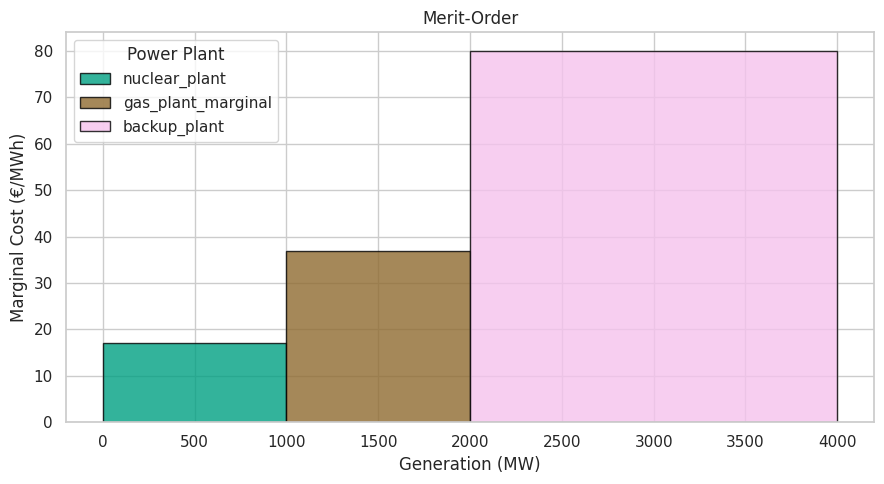

In [8]:
powerplants_path = Path(inputs_path + "/workshop-openmod/powerplant_units_study_1.csv")
power_plants_df = pd.read_csv(powerplants_path)

# Marginal costs are calculated by fuel type, fuel price, co2 price, emission
# factor and additional costs. For simplicity, we use additional costs only.
power_plants_df["marginal_costs"] = power_plants_df["additional_cost"]

fig, ax = plot.plot_merit_order(power_plants_df)

The setup also contains a demand timeseries causing some dynamics in our simulations. Demand is low during night time and higher during the day.

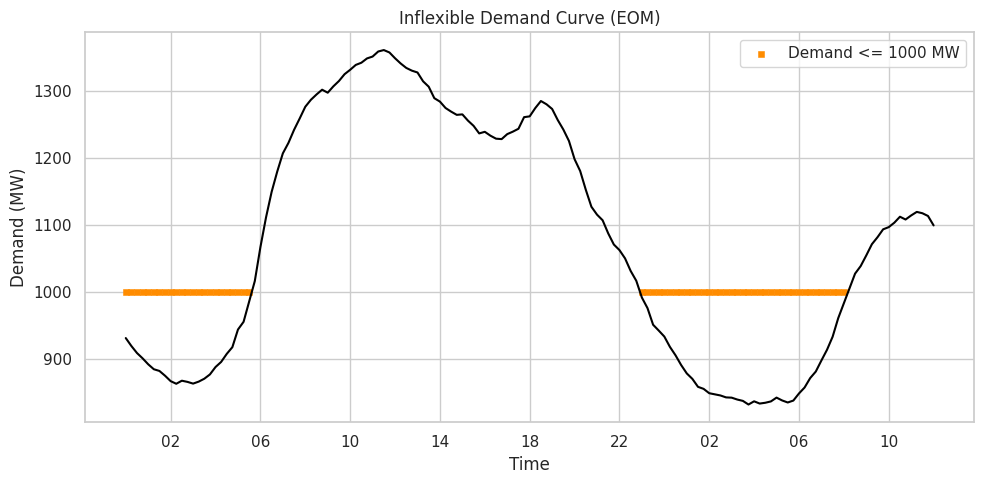

In [9]:
with config_file.open() as fp:
    config = yaml.safe_load(fp)

demand_file = Path(inputs_path + "/workshop-openmod") / "demand_df.csv"
demand_df = pd.read_csv(demand_file, parse_dates=["datetime"])

# Demand df is for full year. We project it to investigated time.
start_time = config["marginal"]["start_date"]
end_time = config["marginal"]["end_date"]

plot_df = demand_df[demand_df["datetime"] >= start_time]
plot_df = plot_df[plot_df["datetime"] <= end_time]

fig, ax = plot.plot_demand(plot_df)

# Study case 1: Gas plant bids marginal costs.
In this first study case, all plants bid their marginal costs. We setup the World, then load the scenario "workshop-openmod" and study case "marginal" from the prebuilt folder.
Last, we call `world.run()` and the simulation starts.

In [10]:
world = World(
    database_uri="",
    export_csv_path=output_dir)

load_scenario_folder(
    world,
    inputs_path=inputs_path,
    scenario="workshop-openmod",
    study_case = "marginal")

world.run()

INFO:assume.scenario.loader_csv:Input files path: /content/repo_assume/examples/inputs/workshop-openmod
INFO:assume.scenario.loader_csv:Study case: marginal
INFO:assume.scenario.loader_csv:Simulation ID: workshop-openmod_marginal
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/unit_operators.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/storage_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/exchange_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/industrial_dsm_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/residential_dsm_units.csv not found. Returning None
INFO:assume.common.utils:Downsampling /content/repo_assume/examples/inputs/workshop-openmod/demand_df.c

After running the simulation, our scenario folder contains a results section, and we are interested in the market_orders.csv file.

Market orders of the medium cost gas plant will be accepted when demand is larger than what the low-cost nuclear plant can cover (>1000 MW).

Text(0.5, 1.0, 'Accepted Volume (Power Plants, Study Case 1)')

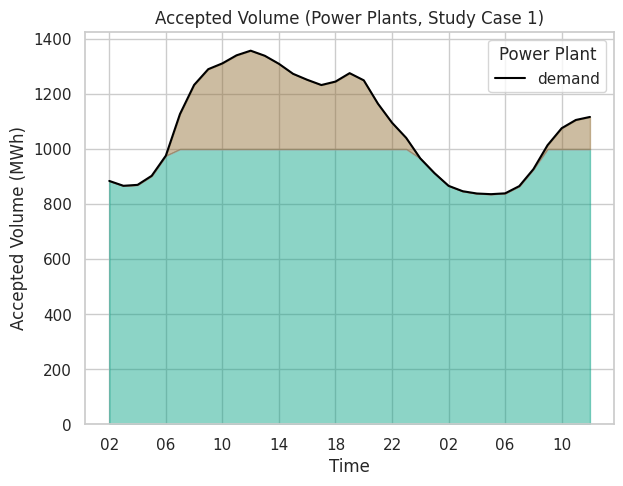

In [11]:
market_orders = pd.read_csv(Path(output_dir) / "workshop-openmod_marginal"  / "market_orders.csv")
fig, ax = plot.plot_accepted_volume(market_orders)
ax.set_title("Accepted Volume (Power Plants, Study Case 1)")


## Study case 2: Gas plant learns its bidding behavior.
In this study case, we equip the gas plant with a Reinforcement Learning (RL) strategy. We do so by switching learning mode to true in the config, setting the learning parameters of the learning_config and including the EnergyLearning strategy in the bidding strategy column of our powerplants_df.csv file. The simulation now will run over and over again, allowing the learning unit to improve its bid price. As before, besides the gas unit, there is nuclear and backup generation.

In [12]:
%%capture
# surpress output.

db_uri = "sqlite:///./examples/local_db/assume_db_learning.db"


with config_file.open() as fp:
    config = yaml.safe_load(fp)

config["learning"]["learning_config"]["training_episodes"] = 10
config["learning"]["learning_config"]["learning_rate"] = 0.002
config["learning"]["learning_config"]["gradient_steps"] = 64
config["learning"]["learning_config"]["train_freq"] = "6h"
config["learning"]["bidding_strategy_params"] = {"foresight": 1}

with config_file.open('w') as fp:
    yaml.safe_dump(config, fp, indent=4, default_flow_style=False)

world = World(
    database_uri=db_uri,
    export_csv_path=output_dir)

load_scenario_folder(
    world,
    inputs_path=inputs_path,
    scenario="workshop-openmod",
    study_case = "learning")

run_learning(world)
world.run()

INFO:assume.world:Connected to the database
INFO:assume.scenario.loader_csv:Input files path: /content/repo_assume/examples/inputs/workshop-openmod
INFO:assume.scenario.loader_csv:Study case: learning
INFO:assume.scenario.loader_csv:Simulation ID: workshop-openmod_learning
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/unit_operators.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/storage_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/exchange_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/industrial_dsm_units.csv not found. Returning None
INFO:assume.scenario.loader_csv:/content/repo_assume/examples/inputs/workshop-openmod/residential_dsm_units.csv not found. Returning None
INFO:assume.common.utils:Downsampling /content/repo_assume/

Accepted volume does not change for learning gas plant.

Text(0.5, 1.0, 'Accepted Volume (Power Plants, Study Case 2)')

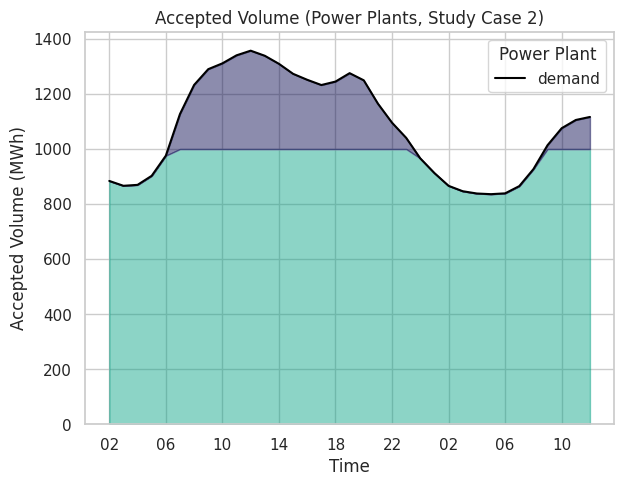

In [13]:
market_orders = pd.read_csv(Path(output_dir) / "workshop-openmod_learning"  / "market_orders.csv")
market_orders.head()

fig, ax = plot.plot_accepted_volume(market_orders)
ax.set_title("Accepted Volume (Power Plants, Study Case 2)")


Accepted volume does not change between study cases. But what about revenue?

Text(0.5, 1.0, 'Offer price: Case 1 vs. Case 2')

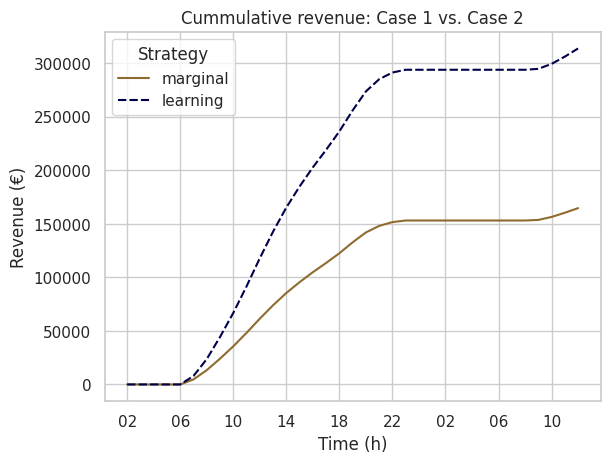

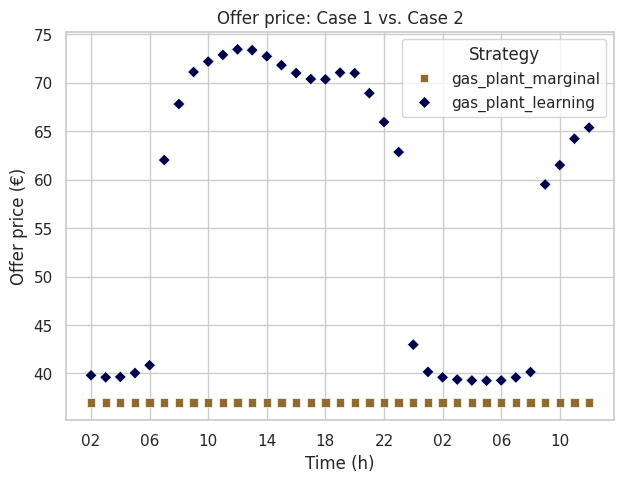

In [14]:
p1 = Path("/content/workshop-openmod_marginal/market_orders.csv")
p2 = Path("/content/workshop-openmod_learning/market_orders.csv")

df1 = pd.read_csv(p1).query("unit_id == 'gas_plant_marginal'")
df2 = pd.read_csv(p2).query("unit_id == 'gas_plant_learning'")

df1["strategy"] = "marginal"
df2["strategy"] = "learning"
df = pd.concat([df1, df2])

fig, ax = plot.plot_revenue(df)
ax.set_title("Cummulative revenue: Case 1 vs. Case 2")

fig, ax = plot.plot_biddings(df)
ax.set_title("Offer price: Case 1 vs. Case 2")

# Study case 3: Two learning gas plants - no nuclear plant.
Lastly, the both **the nuclear AND the gas plant** have RL capabilities. This leads to a more complex RL setting (the Multi Agent Reinforcement Learning, MARL), involving the problems of non-stationarity and non-observability for the learning agents. Backup generation is still there. What do we expect to see in volumes and prices?

#todo:
welche Agenten lernen denn hier? Welche Marginalkosten haben die? Ist es einfach nuclear und gas? Das wäre wichtig zu wissen :)

Ah ne nuclear scheint es nicht zu sein, weil in den Ergebnissen ja gas_plant 1 und 2 steht. Aber haben die dann gleiche Marginalkosten? Und halbes Volumen jeweils, während nuclear gleich bleibt?

In [15]:
%%capture
# Surpress output. This cell will take ~ 2 minutes.


db_uri = "sqlite:///./examples/local_db/assume_db_learning.db"


with config_file.open() as fp:
    config = yaml.safe_load(fp)

config["learning_2_agents"]["learning_config"]["training_episodes"] = 25
config["learning_2_agents"]["learning_config"]["learning_rate"] = 0.001
config["learning_2_agents"]["learning_config"]["gradient_steps"] = 64
config["learning_2_agents"]["learning_config"]["train_freq"] = "5h"
config["learning_2_agents"]["bidding_strategy_params"] = {"foresight": 1}

with config_file.open('w') as fp:
    yaml.safe_dump(config, fp, indent=4, default_flow_style=False)

world = World(
    database_uri=db_uri,
    export_csv_path=output_dir)

load_scenario_folder(
    world,
    inputs_path=inputs_path,
    scenario="workshop-openmod",
    study_case = "learning_2_agents")

run_learning(world)
world.run()



INFO:assume.world:Connected to the database
INFO:assume.common.utils:Downsampling /content/repo_assume/examples/inputs/workshop-openmod/demand_df.csv successful.
INFO:assume.reinforcement_learning.learning_role:New best policy saved, episode: 1, metric='avg_reward', value=0.98


Text(0.5, 1.0, 'Offer prices: Agent 1 vs. Agent 2')

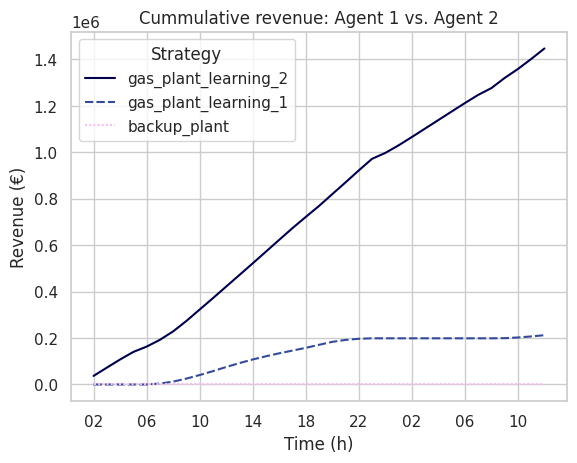

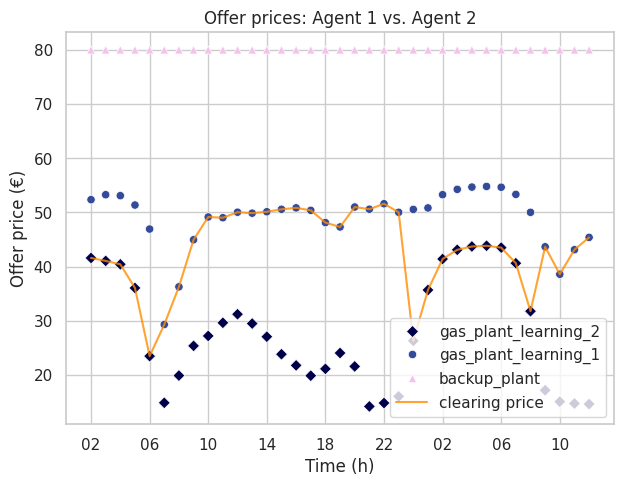

In [16]:
path_market_orders = Path("workshop-openmod_learning_2_agents/market_orders.csv")
market_orders_df = pd.read_csv(path_market_orders)

plot_df = market_orders_df[market_orders_df["unit_id"].str.contains("plant")]

plot_df["strategy"] = plot_df["unit_id"]

fig, ax = plot.plot_revenue(plot_df)
ax.set_title("Cummulative revenue: Agent 1 vs. Agent 2")

fig, ax = plot.plot_biddings_with_clearing_price(plot_df)
ax.set_title("Offer prices: Agent 1 vs. Agent 2")